In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Part (a)

In [4]:
# Define reward distributions for the two arm
def arm1():
    return np.random.normal(6, np.sqrt(15))

def arm2():
    if np.random.rand() < 0.5:
        return np.random.normal(11, np.sqrt(16))
    else:
        return np.random.normal(3, np.sqrt(8))

# Q-value update for epsilon-greedy
def updatedQ(alpha, action, Q, reward):
    Q[action - 1] += alpha * (reward - Q[action - 1])
    return Q

# Epsilon-greedy action selection
def epsilon_greedy(Q, epsilon):
    if np.random.rand() < epsilon:
        return np.random.choice([1, 2])
    else:
        return np.argmax(Q) + 1

In [5]:
def epsilon_greedy_run(steps, alpha_func, Q_init, epsilons):
    rewards = np.zeros((steps, len(epsilons)))
    Q_values = np.zeros((len(epsilons), 2))

    for i, epsilon in enumerate(epsilons):
        Q = Q_init.copy()
        accumulated_reward = 0
        
        for n in range(steps):
            action = epsilon_greedy(Q, epsilon)
            reward = arm1() if action == 1 else arm2()
            accumulated_reward += reward

            rewards[n, i] += accumulated_reward / (n + 1)
            alpha = alpha_func(n + 1)
            Q = updatedQ(alpha, action, Q, reward)

        Q_values[i] = Q
    
    return rewards, Q_values

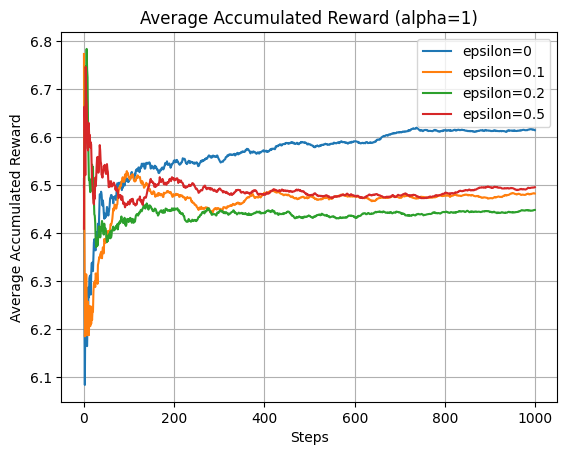

Average Q-values for alpha=1:
 [[-1.08453771  1.24286181]
 [ 2.49133268  3.63816382]
 [ 4.2446171   3.5353303 ]
 [ 4.74639825  6.02534659]]


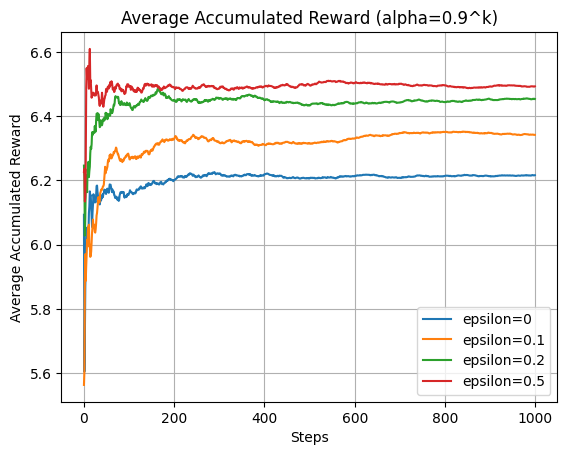

Average Q-values for alpha=0.9^k:
 [[4.42304736 1.39915264]
 [4.7590008  3.11082522]
 [4.77510165 4.33207571]
 [5.44105212 5.80850078]]


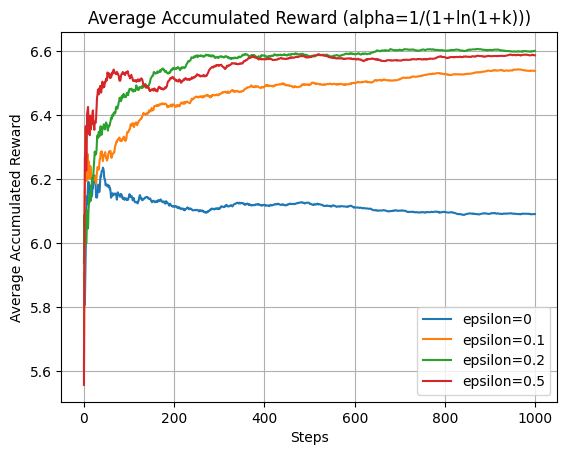

Average Q-values for alpha=1/(1+ln(1+k)):
 [[5.35527123 0.66940428]
 [5.20334571 5.81584318]
 [5.41527101 6.3978256 ]
 [5.59290852 6.6547544 ]]


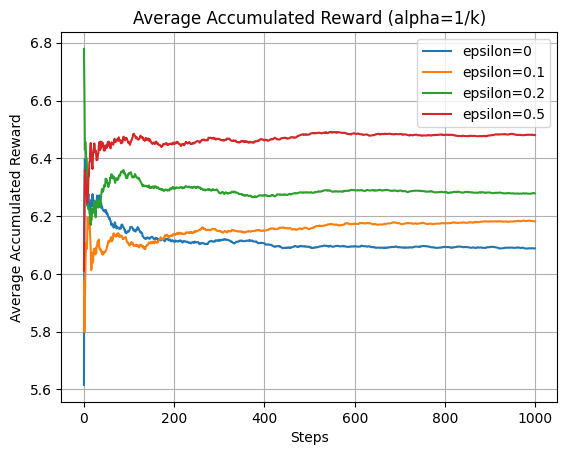

Average Q-values for alpha=1/k:
 [[5.53382411 0.48653569]
 [5.30028451 2.55985837]
 [5.51018228 3.91935167]
 [5.65174191 5.97612805]]


In [18]:
steps = 1000
epsilons = [0, 0.1, 0.2, 0.5]
alpha_funcs = [lambda k: 1,
lambda k: 0.9 ** k,
lambda k: 1 / (1 + np.log(1 + k)),
lambda k: 1 / k]

alpha_labels = ["1", "0.9^k", "1/(1+ln(1+k))", "1/k"]

for j in range(len(alpha_funcs)):
    alpha_func = alpha_funcs[j]
    alpha_label = alpha_labels[j]
    all_rewards = np.zeros((steps, len(epsilons)))
    avg_Q_values = np.zeros((len(epsilons), 2))

    for _ in range(100):
        rewards, Q_values = epsilon_greedy_run(steps, alpha_func, [0, 0], epsilons)
        all_rewards += rewards
        avg_Q_values += Q_values

    all_rewards /= 100
    avg_Q_values /= 100

    for i, epsilon in enumerate(epsilons):
        plt.plot(all_rewards[:, i], label=f"epsilon={epsilon}")

    plt.title(f"Average Accumulated Reward (alpha={alpha_label})")
    plt.xlabel("Steps")
    plt.ylabel("Average Accumulated Reward")
    plt.legend()
    plt.grid()
    plt.show()
    print(f"Average Q-values for alpha={alpha_label}:\n", avg_Q_values)


# Part (b)

[[5.33803896 6.22668056]]
[[5.35696246 6.03787361]]
[[5.16714073 6.65999195]]


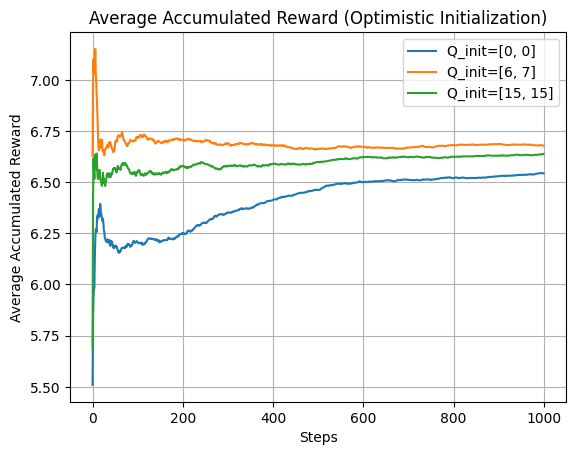

In [16]:
initial_Qs = [[0, 0],
            [6, 7],
            [15, 15]]

for Q_init in initial_Qs:
    all_rewards = np.zeros((steps, 1))
    avg_Q_values = np.zeros((1, 2))

    for _ in range(100):
        rewards, Q_values = epsilon_greedy_run(steps, lambda k: 0.1, Q_init, [0.1])
        all_rewards += rewards
        avg_Q_values += Q_values

    all_rewards /= 100
    avg_Q_values /= 100
    print(avg_Q_values)

    plt.plot(all_rewards, label=f"Q_init={Q_init}")

plt.title("Average Accumulated Reward (Optimistic Initialization)")
plt.xlabel("Steps")
plt.ylabel("Average Accumulated Reward")
plt.legend()
plt.grid()
plt.show()

# Part (c)

In [12]:
def updatedH(alpha, action, H, reward, avg_reward):
    probabilities = np.exp(H) / np.sum(np.exp(H))
    for a in range(len(H)):
        if a == action - 1:
            H[a] += alpha * (reward - avg_reward) * (1 - probabilities[a])
        else:
            H[a] -= alpha * (reward - avg_reward) * probabilities[a]
    return H


def gradient_bandit(steps, alpha):
    H = np.zeros(2)
    probabilities = np.exp(H) / np.sum(np.exp(H))
    rewards = np.zeros(steps)
    accumulated_reward = 0

    for n in range(steps):
        action = np.random.choice([1, 2], p=probabilities)
        reward = arm1() if action == 1 else arm2()
        accumulated_reward += reward
        avg_reward = accumulated_reward / (n + 1)
        H = updatedH(alpha, action, H, reward, avg_reward)
        probabilities = np.exp(H) / np.sum(np.exp(H))
        rewards[n] = avg_reward

    return rewards

gb_rewards = gradient_bandit(1000, 0.1)

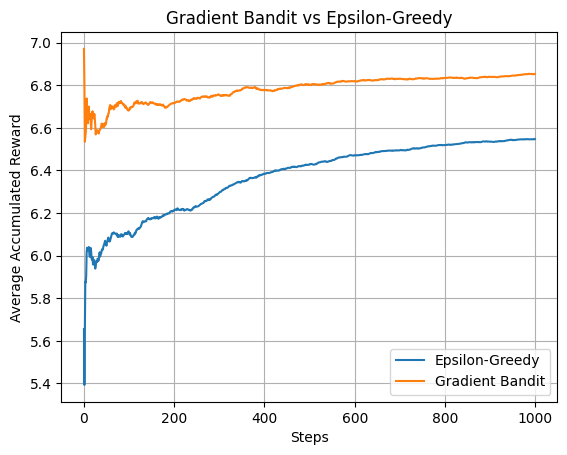

In [14]:
all_rewards_gb = np.zeros(steps)
all_rewards_eg = np.zeros(steps)

for _ in range(100):
    all_rewards_gb += gradient_bandit(steps, 0.1)
    eg_rewards, _ = epsilon_greedy_run(steps, lambda k: 0.1, [0, 0], [0.1])
    all_rewards_eg += eg_rewards[:, 0]

all_rewards_gb /= 100
all_rewards_eg /= 100

plt.plot(all_rewards_eg, label="Epsilon-Greedy")
plt.plot(all_rewards_gb, label="Gradient Bandit")
plt.title("Gradient Bandit vs Epsilon-Greedy")
plt.xlabel("Steps")
plt.ylabel("Average Accumulated Reward")
plt.legend()
plt.grid()
plt.show()
